# SmartBin — Garbage Classification (CNN + Transfer Learning)

A predictive deep-learning model that looks at a photo of a waste item and classifies it into one of
**6 classes**: `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`.

This project creates three models and compares them to find the best predictor for the 6 classes:

1. **Baseline CNN**  (`Conv2D` / `MaxPooling2D` / `Dropout`/`Dense`)
2. **Transfer learning** with **ResNet50** (ImageNet weights, frozen base + custom head)
3. **Fine-tuning** (unfreeze the deeper ResNet50 layers and retrain at a low learning rate)

All model are exported as  `garbage_model_baseline.keras`, `garbage_model_transferlearning.keras`, `garbage_model_finetuned.keras` for the Streamlit app (`app.py`).

> **Dataset:** *Garbage Classification* (TrashNet) — `asdasdasasdas/garbage-classification` on Kaggle.
> ~2,527 images across 6 folders (one folder per class).


## Environment set up

In [6]:
!pip install -q kagglehub

In [7]:
import os, json, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, GlobalAveragePooling2D, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print('TensorFlow', tf.__version__)

TensorFlow 2.20.0


## Get the dataset

`kagglehub` downloads and caches the dataset, then we locate the folder that directly contains the
6 class sub-folders.

In [8]:
import kagglehub

# Downloads to a local cache and returns the path
base_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Downloaded to:", base_path)

# Find the directory that actually holds the class folders (cardboard, glass, ...)
EXPECTED = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}
DATA_DIR = None
for root, dirs, _ in os.walk(base_path):
    if EXPECTED.issubset({d.lower() for d in dirs}):
        DATA_DIR = root
        break

assert DATA_DIR is not None, "Could not locate the 6 class folders — check the dataset layout."
print("Using DATA_DIR:", DATA_DIR)
print("Classes found:", sorted(os.listdir(DATA_DIR)))

Using Colab cache for faster access to the 'garbage-classification' dataset.
Downloaded to: /kaggle/input/garbage-classification
Using DATA_DIR: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Data generators

We rescale pixels to `[0, 1]` and apply light augmentation (rotation, flips, zoom) to the **training**
split only. The validation split gets rescale-only so we evaluate on clean images.
`validation_split=0.2` carves out 20% for validation deterministically (same `seed`).

In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Define class_names directly from DATA_DIR for initial file path collection
class_names = sorted(os.listdir(DATA_DIR))

# Collect all image paths and labels
all_filepaths = []
all_labels = []

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_path):
        all_filepaths.append(os.path.join(class_path, img_name))
        all_labels.append(class_name)

# Create a DataFrame
image_df = pd.DataFrame({'filepath': all_filepaths, 'label': all_labels})

# First split: Separate out the test set (e.g., 20%)
train_val_df, test_df = train_test_split(
    image_df,
    test_size=0.2,
    stratify=image_df['label'], # Stratify to maintain class distribution
    random_state=SEED
)

# Second split: Separate train and validation from the remaining data (e.g., 80/20 of train_val)
# This means: train = 80% of 80% = 64% of total; val = 20% of 80% = 16% of total
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2, # 0.2 of the train_val_df
    stratify=train_val_df['label'],
    random_state=SEED
)

# Training data normalization and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation and Test data normalization (only rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=True
)

val_ds = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

test_ds = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

# Ordered class names (index -> name)
# Ensure class_names and NUM_CLASSES are consistent across all datasets
class_indices = train_ds.class_indices
class_names = [name for name, idx in sorted(class_indices.items(), key=lambda kv: kv[1])]
NUM_CLASSES = len(class_names)
print("Class order:", class_names)

print(f"Train samples: {train_ds.n}")
print(f"Validation samples: {val_ds.n}")
print(f"Test samples: {test_ds.n}")

Found 1616 validated image filenames belonging to 6 classes.
Found 405 validated image filenames belonging to 6 classes.
Found 506 validated image filenames belonging to 6 classes.
Class order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train samples: 1616
Validation samples: 405
Test samples: 506


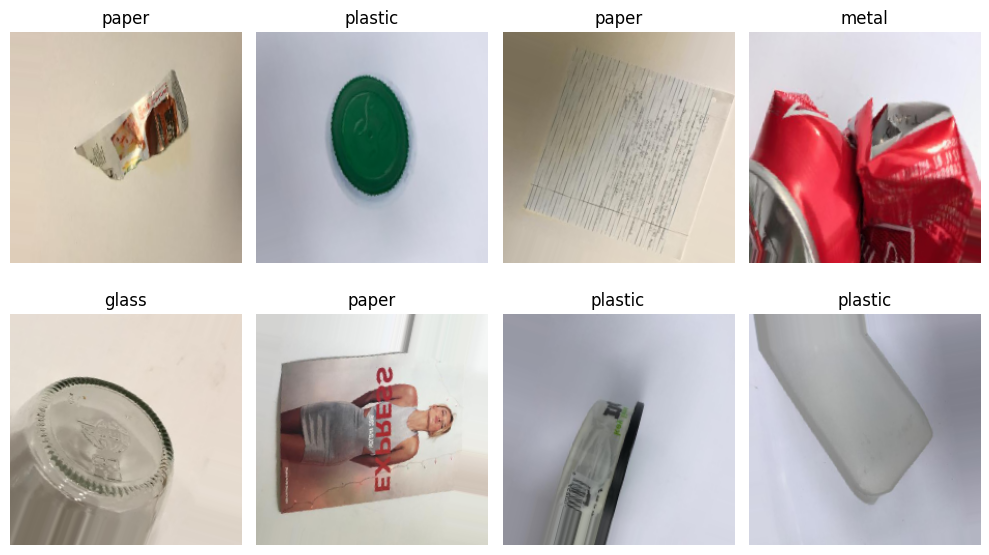

In [10]:
# Image visualization
images, labels = next(train_ds)
plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout(); plt.show()
train_ds.reset()

## Class imbalance

In [11]:
image_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        image_counts[class_name] = len(os.listdir(class_path))

print("Number of images per class:")
for class_name, count in image_counts.items():
    print(f"{class_name}: {count}")


Number of images per class:
cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


The `trash` class has far fewer images than the others. Class weights tell the model to pay more
attention to under-represented classes during training.

In [12]:
y_train = train_ds.classes
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {i: w for i, w in enumerate(weights)}
print({class_names[i]: round(w, 2) for i, w in class_weight.items()})

{'cardboard': np.float64(1.05), 'glass': np.float64(0.84), 'metal': np.float64(1.03), 'paper': np.float64(0.71), 'plastic': np.float64(0.87), 'trash': np.float64(3.06)}


## Baseline CNN

Stacked `Conv2D`, `MaxPooling2D` blocks, then a
dense classifier. This is our honest baseline. Also including a `Dropout` to protect the network from overfitting

In [13]:
def build_cnn():
    m = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(*IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

cnn = build_cnn()
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,910 (19.49 MB)

 Trainable params: 5,107,910 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]
hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=50,
                   class_weight=class_weight, callbacks=cnn_callbacks)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 299s 6s/step - accuracy: 0.3137 - loss: 1.6727 - val_accuracy: 0.3778 - val_loss: 1.5584 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.3948 - loss: 1.4036 - val_accuracy: 0.2840 - val_loss: 1.8862 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 261s 5s/step - accuracy: 0.4313 - loss: 1.3537 - val_accuracy: 0.4765 - val_loss: 1.2982 - learning_rate: 0.0010
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.4616 - loss: 1.3090 - val_accuracy: 0.4765 - val_loss: 1.3644 - learning_rate: 0.0010
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.4752 - loss: 1.2495 - val_accuracy: 0.5333 - val_loss: 1.2762 - learning_rate: 0.0010
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 252s 5s/step - accuracy: 0.5297 - loss: 1.1823 - val_accuracy: 0.4420 - val_loss: 1.3939 - learning_rate: 0.0010
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.5149 - loss: 1.1947 - val_acc

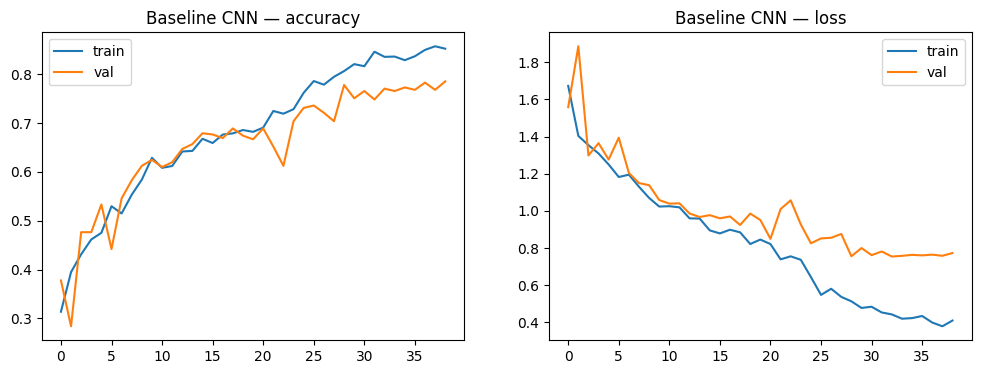

Best baseline CNN val accuracy: 0.785


In [15]:
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history['accuracy'], label='train')
    ax[0].plot(h.history['val_accuracy'], label='val')
    ax[0].set_title(f'{title} — accuracy'); ax[0].legend()
    ax[1].plot(h.history['loss'], label='train')
    ax[1].plot(h.history['val_loss'], label='val')
    ax[1].set_title(f'{title} — loss'); ax[1].legend()
    plt.show()

plot_history(hist_cnn, 'Baseline CNN')
cnn_val_acc = max(hist_cnn.history['val_accuracy'])
print(f"Best baseline CNN val accuracy: {cnn_val_acc:.3f}")

Save basic model

In [16]:
best = cnn

best.save('garbage_model_baseline.keras')

config = {
    "class_names": class_names,
    "img_size": list(IMG_SIZE),
    "recyclable": ["cardboard", "glass", "metal", "paper", "plastic"],  # 'trash' -> landfill
}
with open('class_names.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved garbage_model.keras and class_names.json")
print("Download both files and place them next to app.py.")

Saved garbage_model.keras and class_names.json
Download both files and place them next to app.py.


##  Transfer learning with ResNet50

We load **ResNet50** pretrained on ImageNet without its top, **freeze** every layer, and train only a
small custom head. The pretrained filters already recognise edges, textures and materials, so this
learns our 6 classes from far fewer images than training from scratch.

In [17]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False,
    input_tensor=Input(shape=(*IMG_SIZE, 3)))

for layer in base_model.layers:
    layer.trainable = False

head = base_model.output
head = GlobalAveragePooling2D()(head)
head = Dense(256, activation='relu')(head)
head = Dropout(0.2)(head)
head = Dense(NUM_CLASSES, activation='softmax')(head)

network = Model(inputs=base_model.input, outputs=head)
network.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Trainable params (head only):",
      f"{int(np.sum([tf.size(w).numpy() for w in network.trainable_weights])):,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable params (head only): 526,086


In [18]:
network.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
tl_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]
hist_tl = network.fit(train_ds, validation_data=val_ds, epochs=40,
                      class_weight=class_weight, callbacks=tl_callbacks)
plot_history(hist_tl, 'Transfer learning (frozen ResNet50)')
tl_val_acc = max(hist_tl.history['val_accuracy'])
print(f"Best transfer-learning val accuracy: {tl_val_acc:.3f}")

Epoch 1/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 441s 8s/step - accuracy: 0.1949 - loss: 1.8783 - val_accuracy: 0.2642 - val_loss: 1.7566 - learning_rate: 0.0010
Epoch 2/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 423s 8s/step - accuracy: 0.2184 - loss: 1.7559 - val_accuracy: 0.2864 - val_loss: 1.6710 - learning_rate: 0.0010
Epoch 3/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 425s 8s/step - accuracy: 0.2413 - loss: 1.7343 - val_accuracy: 0.2568 - val_loss: 1.6764 - learning_rate: 0.0010
Epoch 4/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 421s 8s/step - accuracy: 0.2469 - loss: 1.7212 - val_accuracy: 0.2543 - val_loss: 1.6682 - learning_rate: 0.0010
Epoch 5/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 425s 8s/step - accuracy: 0.2512 - loss: 1.7336 - val_accuracy: 0.3407 - val_loss: 1.6597 - learning_rate: 0.0010
Epoch 6/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 419s 8s/step - accuracy: 0.2661 - loss: 1.7146 - val_accuracy: 0.3580 - val_loss: 1.6680 - learning_rate: 0.0010
Epoch 7/40
51/51 ━━━━━━━━━━━━━━━━━━━━ 417s 8s/step - accuracy: 0.2748 - loss: 1.6984 - val_acc

KeyboardInterrupt: 

Save the Transferlearning model

In [ ]:

best = network   # change to `cnn` if the baseline somehow wins

best.save('garbage_model_transferlearning.keras')

config = {
    "class_names": class_names,
    "img_size": list(IMG_SIZE),
    "recyclable": ["cardboard", "glass", "metal", "paper", "plastic"],  # 'trash' -> landfill
}
with open('class_names.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved garbage_model.keras and class_names.json")
print("Download both files and place them next to app.py.")

## Fine-tuning

Now we **unfreeze the deeper layers** of ResNet50 and continue training with a **very low learning
rate** (1e-5). This gently adapts the high-level ImageNet filters to recycling materials specifically.
We keep the early, generic layers frozen.

In [ ]:
FINE_TUNE_AT = 140   # unfreeze layers from this index onward
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

# Recompile with a low LR so we don't wreck the pretrained weights
network.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='categorical_crossentropy', metrics=['accuracy'])

ft_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
]
hist_ft = network.fit(train_ds, validation_data=val_ds, epochs=30,
                      class_weight=class_weight, callbacks=ft_callbacks)
plot_history(hist_ft, 'Fine-tuned ResNet50')
ft_val_acc = max(hist_ft.history['val_accuracy'])
print(f"Best fine-tuned val accuracy: {ft_val_acc:.3f}")

Save Fine tuned model

In [ ]:
best = network

best.save('garbage_model_finetuned.keras')

config = {
    "class_names": class_names,
    "img_size": list(IMG_SIZE),
    "recyclable": ["cardboard", "glass", "metal", "paper", "plastic"],  # 'trash' -> landfill
}
with open('class_names.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved garbage_model.keras and class_names.json")
print("Download both files and place them next to app.py.")

## Evaluate & compare
Line up the three approaches, then inspect the winner with a confusion matrix and a full report.

In [ ]:
print('Evaluating models on the test set...')

# Reset test_ds for consistent evaluation across models
test_ds.reset()

# --- 1. Evaluate Baseline CNN ---
# The `cnn` variable holds the trained Baseline CNN model
cnn_test_loss, cnn_test_acc = cnn.evaluate(test_ds, verbose=0)
print(f"Baseline CNN Test Accuracy: {cnn_test_acc:.3f}")

# --- 2. Evaluate Transfer Learning model (before fine-tuning) ---
# Load the saved transfer learning model to evaluate its performance before fine-tuning
tl_model = tf.keras.models.load_model('garbage_model_transferlearning.keras')
tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=0)
print(f"Transfer Learning Test Accuracy: {tl_test_acc:.3f}")

# --- 3. Evaluate Fine-tuned ResNet50 model ---
# The `network` variable currently holds the fine-tuned ResNet50 model
ft_test_loss, ft_test_acc = network.evaluate(test_ds, verbose=0)
print(f"Fine-tuned ResNet50 Test Accuracy: {ft_test_acc:.3f}")

In [ ]:
print("Test accuracy comparison:")
print("-" * 38)
print(f"A) Baseline CNN          : {cnn_test_acc:.3f}")
print(f"B) Transfer learning     : {tl_test_acc:.3f}")
print(f"C) Fine-tuned ResNet50   : {ft_test_acc:.3f}")

In [ ]:
print("Validation accuracy comparison")
print("-" * 38)
print(f"A) Baseline CNN          : {cnn_val_acc:.3f}")
print(f"B) Transfer learning     : {tl_val_acc:.3f}")
print(f"C) Fine-tuned ResNet50   : {ft_val_acc:.3f}")

In [ ]:
val_ds.reset()
probs = network.predict(val_ds)
y_pred = np.argmax(probs, axis=1)
y_true = val_ds.classes

print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix — fine-tuned ResNet50')
plt.show()

## Save the model for the app

We export the **full** fine-tuned model plus a small config file the Streamlit app reads
(class order, image size, and which classes count as recyclable).

In [ ]:
if cnn_test_acc > ft_test_acc:
    best = cnn
    print("Baseline CNN is the best performing model.")
else:
    best = network
    print("Fine-tuned ResNet50 is the best performing model.")

best.save('garbage_model.keras')

config = {
    "class_names": class_names,
    "img_size": list(IMG_SIZE),
    "recyclable": ["cardboard", "glass", "metal", "paper", "plastic"],  # 'trash' -> landfill
}
with open('class_names.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved garbage_model.keras and class_names.json")
print("Download both files and place them next to app.py.")

In [ ]:
# In Colab, trigger downloads of the two files the app needs:
try:
    from google.colab import files
    files.download('garbage_model.keras')
    files.download('garbage_model_baseline.keras')
    files.download('garbage_model_transferlearning.keras')
    files.download('garbage_model_finetuned.keras')
    files.download('class_names.json')
except Exception as e:
    print("Not on Colab — grab the files from the working directory.", e)

## 10. Quick single-image sanity check
Same preprocessing the app uses: resize → rescale by 1/255 → add batch dim → predict.

In [ ]:
def predict_path(path):
    img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE)
    arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    p = best.predict(arr, verbose=0)[0]
    i = int(np.argmax(p))
    print(f"Prediction: {class_names[i]}  ({p[i]*100:.1f}% confidence)")
    return class_names[i]

# Example: grab one validation image path and test it
val_ds.reset()
sample_path = os.path.join(DATA_DIR, val_ds.filenames[0])
print("Testing:", sample_path)
predict_path(sample_path)